In [1]:
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
import time
from collections import Counter

print("Bibliothèques importées avec succès")

Bibliothèques importées avec succès


In [2]:
df = pd.read_csv("dataset/user_behavior_dataset_cleaned.csv")
print(f"Shape du dataset : {df.shape}")
print("\nAperçu des 5 premières lignes :")
display(df.head())

transactions = df.values.tolist()
transactions = [[str(item).strip() for item in t if pd.notna(item)] for t in transactions]
transactions = [t for t in transactions if t]

n = len(transactions)
print(f"\nNombre de transactions : {n}")

Shape du dataset : (700, 10)

Aperçu des 5 premières lignes :


,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,Google Pixel 5,Android,Forte utilisation,Écran modérément allumé,Consommation moyenne batterie,Beaucoup d'apps,Consommation data modérée,Adulte,Homme,Comportement intensif
1,OnePlus 9,Android,Utilisation modérée,Écran modérément allumé,Consommation moyenne batterie,Nombre moyen d'apps,Consommation data modérée,Adulte senior,Femme,Comportement moyen
2,Xiaomi Mi 11,Android,Utilisation modérée,Écran modérément allumé,Faible consommation batterie,Nombre moyen d'apps,Faible consommation data,Adulte senior,Homme,Comportement léger
3,Google Pixel 5,Android,Utilisation modérée,Écran modérément allumé,Consommation moyenne batterie,Nombre moyen d'apps,Consommation data modérée,Jeune adulte,Homme,Comportement moyen
4,iPhone 12,iOS,Utilisation modérée,Écran modérément allumé,Consommation moyenne batterie,Nombre moyen d'apps,Consommation data modérée,Adulte,Femme,Comportement moyen



Nombre de transactions : 700


In [3]:
def get_support(itemset, transactions, n):
    if not itemset:
        return 0.0
    itemset = set(itemset)
    count = sum(1 for t in transactions if itemset.issubset(t))
    return count / n

def compute_dynamic_thresholds(transactions):
    lengths = [len(t) for t in transactions]
    avg_len = np.mean(lengths)
    
    items = list(set(item for t in transactions for item in t))
    unique_items = len(items)

    minsup_global = avg_len / unique_items
    
    supports = [get_support([item], transactions, len(transactions)) for item in items]
    std = np.std(supports)
    median = np.median(supports) 

    minsup = minsup_global + (0.1 * std) + (0.2 * median)
    minsup = min(max(minsup, 0.05), 0.3)

    minconf = 0.5 + 0.3 * std
    minconf = min(max(minconf, 0.5), 0.9)

    return minsup, minconf

In [4]:
def apriori(transactions, minsup):
    n = len(transactions)
    items = list(set(item for t in transactions for item in t))
    
    L = []
    for item in items:
        s = get_support([item], transactions, n)
        if s >= minsup:
            L.append((tuple([item]), s))
    
    freq = L[:]
    k = 2
    
    while L and k <= 6: 
        unique_items = set()
        for itemset, _ in L:
            unique_items.update(itemset)

        candidates = list(combinations(sorted(unique_items), k))

        L = []
        for c in candidates:
            s = get_support(c, transactions, n)
            if s >= minsup:
                L.append((c, s))

        freq.extend(L)
        k += 1
    
    return freq

In [5]:
def generate_rules(freq, transactions, minconf):
    n = len(transactions)
    rules = []

    for itemset, sup in freq:
        if len(itemset) < 2:
            continue

        for i in range(1, len(itemset)):
            for A in combinations(itemset, i):
                A = tuple(A)
                B = tuple(set(itemset) - set(A))
                if not B:
                    continue

                supA = get_support(A, transactions, n)
                supB = get_support(B, transactions, n)

                if supA == 0 or supB == 0:
                    continue

                conf = sup / supA
                lift = conf / supB

                if conf >= minconf and lift > 1.1:
                    rules.append((A, B, sup, conf, lift))

    return rules

In [6]:
minsup_dyn, minconf_dyn = compute_dynamic_thresholds(transactions)

print("Paramètres dynamiques")
print(f"minsup  = {round(minsup_dyn, 3)}")
print(f"minconf = {round(minconf_dyn, 3)}\n")

start = time.time()

freq_classic = apriori(transactions, 0.20)
rules_classic = generate_rules(freq_classic, transactions, 0.6)

freq_hybrid = apriori(transactions, minsup_dyn)
rules_hybrid = generate_rules(freq_hybrid, transactions, minconf_dyn)

print(f"Temps total d'exécution : {time.time() - start:.2f} secondes")

Paramètres dynamiques
minsup  = 0.3
minconf = 0.537

Temps total d'exécution : 5.71 secondes


In [7]:
def analyze_rules(rules):
    if not rules:
        return 0, 0, 0
    avg_sup = np.mean([r[2] for r in rules])
    avg_conf = np.mean([r[3] for r in rules])
    avg_lift = np.mean([r[4] for r in rules])
    return avg_sup, avg_conf, avg_lift

sup_c, conf_c, lift_c = analyze_rules(rules_classic)
sup_h, conf_h, lift_h = analyze_rules(rules_hybrid)

print("\n" + "="*65)
print(" COMPARAISON APRIORI CLASSIQUE vs VERSION AMÉLIORÉE ")
print("="*65)
print(f"{'Métrique':<20} {'Classique (0.20)':<18} {'Dynamique':<15}")
print("-"*65)
print(f"{'Itemsets fréquents':<20} {len(freq_classic):<18} {len(freq_hybrid):<15}")
print(f"{'Règles générées':<20} {len(rules_classic):<18} {len(rules_hybrid):<15}")
print(f"{'Support moyen':<20} {sup_c:.4f}            {sup_h:.4f}")
print(f"{'Confiance moyenne':<20} {conf_c:.4f}            {conf_h:.4f}")
print(f"{'Lift moyen':<20} {lift_c:.4f}            {lift_h:.4f}")
print("="*65)


 COMPARAISON APRIORI CLASSIQUE vs VERSION AMÉLIORÉE 
Métrique             Classique (0.20)   Dynamique      
-----------------------------------------------------------------
Itemsets fréquents   290                36             
Règles générées      2226               32             
Support moyen        0.2258            0.3350
Confiance moyenne    0.8321            0.9244
Lift moyen           2.9484            2.5336


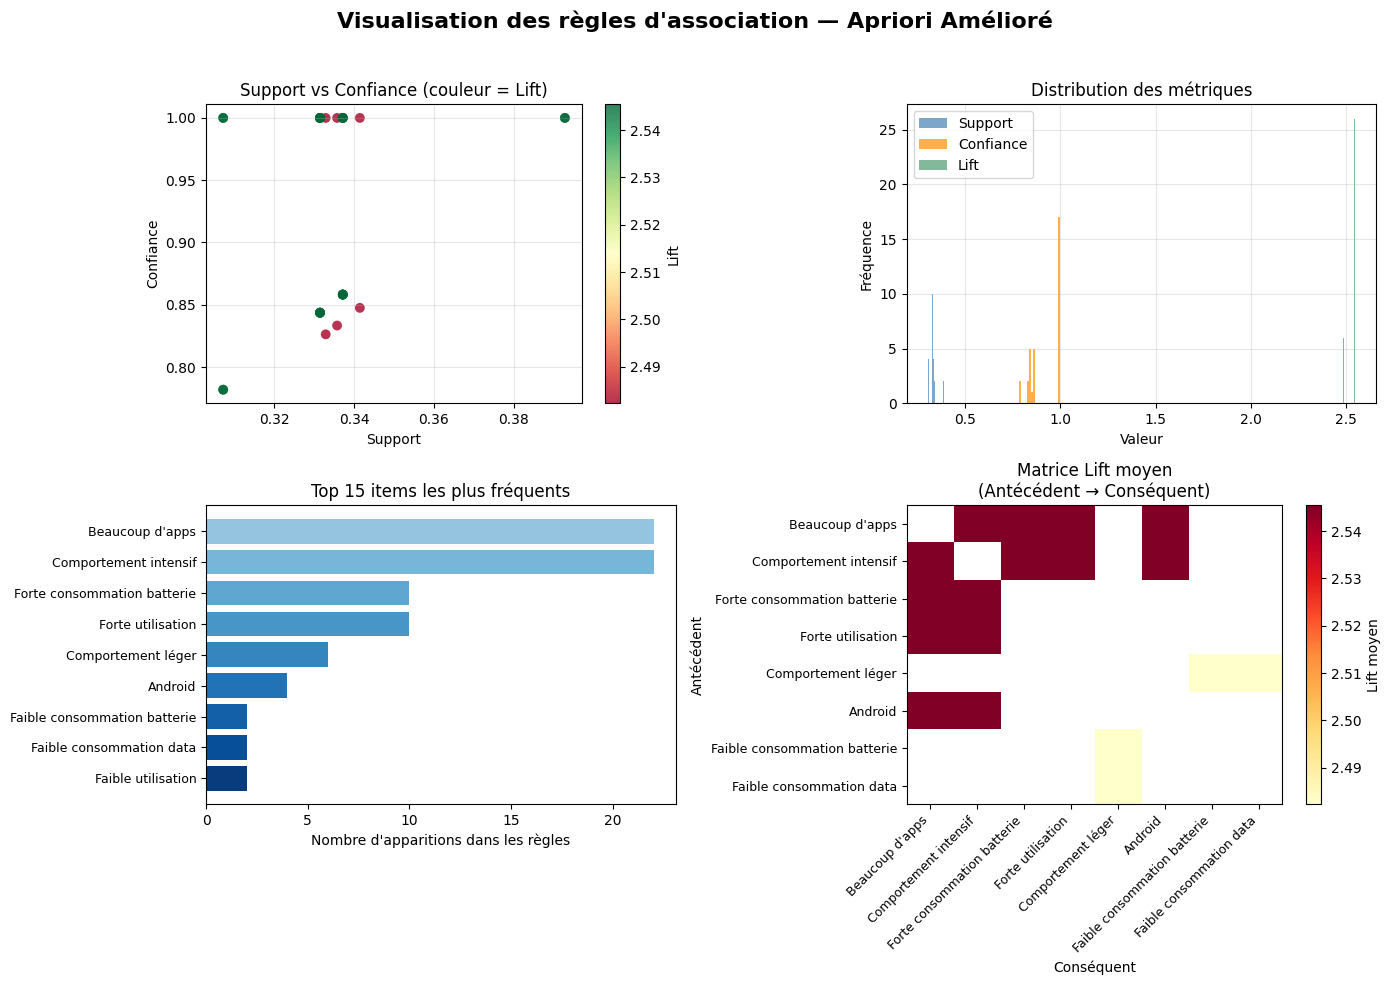

Visualisation sauvegardée sous : visualisations_regles_apriori.png


In [8]:
regles = rules_hybrid

supports_vals   = [r[2] for r in regles]
confiances_vals = [r[3] for r in regles]
lifts_vals      = [r[4] for r in regles]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Visualisation des règles d'association — Apriori Amélioré", 
             fontsize=16, fontweight="bold", y=0.98)

ax1 = axes[0, 0]
sc = ax1.scatter(supports_vals, confiances_vals, c=lifts_vals, cmap="RdYlGn", 
                 s=50, alpha=0.8, edgecolors="none")
plt.colorbar(sc, ax=ax1, label="Lift")
ax1.set_xlabel("Support")
ax1.set_ylabel("Confiance")
ax1.set_title("Support vs Confiance (couleur = Lift)")
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.hist(supports_vals,   bins=20, alpha=0.7, label="Support",   color="steelblue")
ax2.hist(confiances_vals, bins=20, alpha=0.7, label="Confiance", color="darkorange")
ax2.hist(lifts_vals,      bins=20, alpha=0.6, label="Lift",      color="seagreen")
ax2.set_xlabel("Valeur")
ax2.set_ylabel("Fréquence")
ax2.set_title("Distribution des métriques")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
all_items = [item for ant, cons, *_ in regles for item in list(ant) + list(cons)]
item_counts = Counter(all_items).most_common(15)
items_noms, items_freq = zip(*item_counts)

colors_bar = plt.cm.Blues(np.linspace(0.4, 0.95, len(items_noms)))
ax3.barh(items_noms[::-1], items_freq[::-1], color=colors_bar[::-1])
ax3.set_xlabel("Nombre d'apparitions dans les règles")
ax3.set_title("Top 15 items les plus fréquents")
ax3.tick_params(axis="y", labelsize=9)

ax4 = axes[1, 1]
top_items = [i for i, _ in Counter(all_items).most_common(8)]
matrix = np.zeros((len(top_items), len(top_items)))
counts = np.zeros((len(top_items), len(top_items)), dtype=int)

for ant, cons, sup, conf, lift in regles:
    for a in ant:
        for c in cons:
            if a in top_items and c in top_items:
                i = top_items.index(a)
                j = top_items.index(c)
                matrix[i][j] += lift
                counts[i][j] += 1

with np.errstate(invalid="ignore"):
    avg_lift = np.where(counts > 0, matrix / counts, np.nan)

im = ax4.imshow(avg_lift, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax4, label="Lift moyen")
ax4.set_xticks(range(len(top_items)))
ax4.set_yticks(range(len(top_items)))
ax4.set_xticklabels(top_items, rotation=45, ha="right", fontsize=9)
ax4.set_yticklabels(top_items, fontsize=9)
ax4.set_title("Matrice Lift moyen\n(Antécédent → Conséquent)")
ax4.set_xlabel("Conséquent")
ax4.set_ylabel("Antécédent")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("visualisations_regles_apriori.png", dpi=180, bbox_inches="tight")
plt.show()

print("Visualisation sauvegardée sous : visualisations_regles_apriori.png")

In [9]:
print("\n=== TOP 15 RÈGLES - VERSION AMÉLIORÉE (triées par Lift) ===\n")

rules_hybrid_sorted = sorted(rules_hybrid, key=lambda x: x[4], reverse=True)

for i, (A, B, sup, conf, lift) in enumerate(rules_hybrid_sorted[:15], 1):
    print(f"Règle {i:2d}: {A}  ==>  {B}")
    print(f"   Support = {sup:.4f} | Confiance = {conf:.4f} | Lift = {lift:.3f}")
    print("-" * 60)


=== TOP 15 RÈGLES - VERSION AMÉLIORÉE (triées par Lift) ===

Règle  1: ("Beaucoup d'apps",)  ==>  ('Comportement intensif',)
   Support = 0.3929 | Confiance = 1.0000 | Lift = 2.545
------------------------------------------------------------
Règle  2: ('Comportement intensif',)  ==>  ("Beaucoup d'apps",)
   Support = 0.3929 | Confiance = 1.0000 | Lift = 2.545
------------------------------------------------------------
Règle  3: ("Beaucoup d'apps",)  ==>  ('Forte consommation batterie',)
   Support = 0.3314 | Confiance = 0.8436 | Lift = 2.545
------------------------------------------------------------
Règle  4: ('Forte consommation batterie',)  ==>  ("Beaucoup d'apps",)
   Support = 0.3314 | Confiance = 1.0000 | Lift = 2.545
------------------------------------------------------------
Règle  5: ("Beaucoup d'apps",)  ==>  ('Forte utilisation',)
   Support = 0.3371 | Confiance = 0.8582 | Lift = 2.545
------------------------------------------------------------
Règle  6: ('Forte utilisa